# Supply Chain Analytics

## Project Overview

This project analyzes supply chain operations using Python, SQL Server, and Power BI.

The objective is to explore sales, inventory, supplier, warehouse, and demand-related data to identify operational patterns and generate actionable business insights.

The analysis covers:

- Sales and demand analysis
- Inventory performance
- Supplier performance
- Warehouse performance
- Order quantity analysis
- Demand forecasting and forecast error
- Stockout analysis
- Inventory turnover
- SKU-level performance
- Monthly supply chain trends

The project follows an end-to-end analytics workflow:

**Data Preparation → Exploratory Data Analysis → SQL Analysis → Power BI Dashboard**

The final objective is to transform raw supply chain data into meaningful insights that can support inventory planning, demand management, supplier evaluation, and operational decision-making.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load the Dataset

The supply chain dataset contains transactional and operational information related to products, warehouses, suppliers, sales, inventory, pricing, promotions, and demand forecasting.

The dataset includes the following key variables:

- **Date** – Date of the supply chain record
- **SKU_ID** – Product identifier
- **Warehouse_ID** – Warehouse identifier
- **Supplier_ID** – Supplier identifier
- **Region** – Geographic region
- **Units_Sold** – Number of units sold
- **Inventory_Level** – Available inventory
- **Supplier_Lead_Time_Days** – Supplier delivery lead time
- **Reorder_Point** – Inventory level at which replenishment is triggered
- **Order_Quantity** – Quantity ordered
- **Unit_Cost** – Cost per unit
- **Unit_Price** – Selling price per unit
- **Promotion_Flag** – Indicates whether a promotion was active
- **Stockout_Flag** – Indicates whether a stockout occurred
- **Demand_Forecast** – Forecasted demand
- **Forecast Error** – Difference between actual and forecast demand

The dataset will be loaded into a Pandas DataFrame for data validation, exploratory analysis, and subsequent analytical processing.

In [3]:
from pathlib import Path

data_path = Path("../Data")

supply_chain = pd.read_csv(
    data_path / "supply_chain_dataset.csv"
)

print("Dataset Shape:", supply_chain.shape)

display(supply_chain.head())

Dataset Shape: (91250, 15)


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,01-01-2024,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,02-01-2024,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,03-01-2024,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,04-01-2024,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,05-01-2024,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


## 2. Initial Data Exploration

Before performing detailed analysis, the dataset is inspected to understand its structure, variables, and overall data quality.

This initial exploration includes:

- Reviewing sample records
- Examining the dataset dimensions
- Checking the data types of each column
- Checking for missing values
- Checking for duplicate records

This step helps ensure that the dataset is suitable for further analysis and identifies any data-quality issues that may need to be addressed.

In [4]:
# Display basic dataset information

print("Dataset Shape:")
print(supply_chain.shape)

print("\nColumn Names:")
print(supply_chain.columns.tolist())

print("\nFirst 5 Records:")
display(supply_chain.head())

Dataset Shape:
(91250, 15)

Column Names:
['Date', 'SKU_ID', 'Warehouse_ID', 'Supplier_ID', 'Region', 'Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag', 'Stockout_Flag', 'Demand_Forecast']

First 5 Records:


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,01-01-2024,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,02-01-2024,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,03-01-2024,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,04-01-2024,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,05-01-2024,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


### 2.1 Data Types

The data types of each column are examined to ensure that numerical, categorical, and date-related variables are represented appropriately for analysis.

In [5]:
# Check data types of all columns

print("Data Types:")
print(supply_chain.dtypes)

Data Types:
Date                           str
SKU_ID                         str
Warehouse_ID                   str
Supplier_ID                    str
Region                         str
Units_Sold                   int64
Inventory_Level              int64
Supplier_Lead_Time_Days      int64
Reorder_Point                int64
Order_Quantity               int64
Unit_Cost                  float64
Unit_Price                 float64
Promotion_Flag               int64
Stockout_Flag                int64
Demand_Forecast            float64
dtype: object


### 2.2 Missing Value Analysis

Missing values are checked across all columns to assess the completeness of the dataset.

Identifying missing values is important because incomplete records can affect calculations, aggregations, and subsequent analytical results.

In [6]:
# Check for missing values

missing_values = supply_chain.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Date                       0
SKU_ID                     0
Warehouse_ID               0
Supplier_ID                0
Region                     0
Units_Sold                 0
Inventory_Level            0
Supplier_Lead_Time_Days    0
Reorder_Point              0
Order_Quantity             0
Unit_Cost                  0
Unit_Price                 0
Promotion_Flag             0
Stockout_Flag              0
Demand_Forecast            0
dtype: int64


### 2.3 Duplicate Record Analysis

The dataset is checked for duplicate rows to determine whether identical records are present.

Removing or identifying duplicate records is important because duplicates can lead to inflated totals and inaccurate analytical results.

In [7]:
# Check for duplicate records

duplicate_count = supply_chain.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


### 3. Data Preparation

Before performing detailed analysis, the dataset is prepared by converting date-related fields into appropriate formats.

### 3.1 Date Conversion

The `Date` column is converted from its original representation into a Pandas datetime format. This enables time-based analysis such as monthly trends, yearly summaries, and date-based aggregations.

In [8]:
# Convert Date column to datetime

supply_chain["Date"] = pd.to_datetime(
    supply_chain["Date"],
    errors="coerce"
)

print("Date Data Type:")
print(supply_chain["Date"].dtype)

print("\nDate Range:")
print(supply_chain["Date"].min(), "to", supply_chain["Date"].max())

Date Data Type:
datetime64[us]

Date Range:
2024-01-01 00:00:00 to 2024-12-12 00:00:00


### 3.2 Date Feature Creation

Additional date features are created from the `Date` column to support time-based analysis.

The extracted year, month number, and month name will be used for monthly and yearly supply chain performance analysis.

In [9]:
# Create date-based features

supply_chain["Year"] = supply_chain["Date"].dt.year
supply_chain["Month"] = supply_chain["Date"].dt.month
supply_chain["Month_Name"] = supply_chain["Date"].dt.month_name()

display(
    supply_chain[
        ["Date", "Year", "Month", "Month_Name"]
    ].head()
)

,Date,Year,Month,Month_Name
0,2024-01-01,"2,024.00",1.00,January
1,2024-02-01,"2,024.00",2.00,February
2,2024-03-01,"2,024.00",3.00,March
3,2024-04-01,"2,024.00",4.00,April
4,2024-05-01,"2,024.00",5.00,May


### 3.3 Descriptive Statistics

Descriptive statistics are calculated for the numerical variables to understand their central tendency, dispersion, and overall distribution.

This provides an initial quantitative overview of sales, inventory, supplier lead time, order quantities, costs, prices, and demand-related variables.

In [10]:
# Generate descriptive statistics for numerical columns

numeric_summary = supply_chain.describe().T

display(numeric_summary)

,count,mean,min,25%,50%,75%,max,std
Date,36000,2024-06-21 20:00:00,2024-01-01 00:00:00,2024-03-27 00:00:00,2024-06-21 12:00:00,2024-09-16 18:00:00,2024-12-12 00:00:00,NaN
Units_Sold,"91,250.00",20.05,0.00,13.00,20.00,27.00,59.00,9.07
Inventory_Level,"91,250.00",471.52,168.00,370.00,461.00,564.00,990.00,133.49
Supplier_Lead_Time_Days,"91,250.00",7.98,2.00,4.00,8.00,11.00,14.00,3.91
Reorder_Point,"91,250.00",300.07,201.00,252.00,300.00,346.00,398.00,54.88
Order_Quantity,"91,250.00",19.27,0.00,0.00,0.00,0.00,499.00,82.34
Unit_Cost,"91,250.00",12.20,5.02,8.18,11.99,16.32,19.76,4.57
Unit_Price,"91,250.00",18.26,6.95,12.00,18.18,23.39,35.10,7.12
Promotion_Flag,"91,250.00",0.10,0.00,0.00,0.00,0.00,1.00,0.30
Stockout_Flag,"91,250.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00


## 4. Promotion Analysis

Promotional activity is analyzed to understand how promotions relate to sales performance.

The analysis compares records with and without promotions based on units sold and other relevant sales measures. This helps identify whether promotional periods are associated with differences in demand and sales volume.

In [11]:
# Analyze sales performance by promotion status

promotion_analysis = (
    supply_chain
    .groupby("Promotion_Flag")
    .agg(
        records=("SKU_ID", "count"),
        total_units_sold=("Units_Sold", "sum"),
        average_units_sold=("Units_Sold", "mean")
    )
    .reset_index()
)

display(promotion_analysis)

,Promotion_Flag,records,total_units_sold,average_units_sold
0,0,81980,1599018,19.50
1,1,9270,230961,24.91


## 5. Inventory Analysis

Inventory levels are analyzed to understand the availability of stock across the supply chain.

The analysis examines inventory levels in relation to sales activity and reorder points. This helps identify overall inventory patterns and provides a basis for evaluating inventory efficiency and potential stock-related issues.

In [12]:
# Inventory Analysis

print("Inventory Statistics:")

print("\nAverage Inventory Level:")
print(round(supply_chain["Inventory_Level"].mean(), 2))

print("\nMinimum Inventory Level:")
print(supply_chain["Inventory_Level"].min())

print("\nMaximum Inventory Level:")
print(supply_chain["Inventory_Level"].max())

print("\nAverage Reorder Point:")
print(round(supply_chain["Reorder_Point"].mean(), 2))

print("\nAverage Order Quantity:")
print(round(supply_chain["Order_Quantity"].mean(), 2))

Inventory Statistics:

Average Inventory Level:
471.52

Minimum Inventory Level:
168

Maximum Inventory Level:
990

Average Reorder Point:
300.07

Average Order Quantity:
19.27


## 6. Stockout Analysis

Stockout records are analyzed to assess the occurrence of inventory shortages within the supply chain.

The analysis examines the distribution of stockout records and compares operational activity across stockout and non-stockout periods. This helps evaluate whether inventory availability is affecting supply chain performance.

In [13]:
# Stockout Analysis

print("Stockout Distribution:")

stockout_analysis = (
    supply_chain["Stockout_Flag"]
    .value_counts()
    .reset_index()
)

stockout_analysis.columns = [
    "Stockout_Flag",
    "Records"
]

display(stockout_analysis)

Stockout Distribution:


,Stockout_Flag,Records
0,0,91250


## 7. Inventory Turnover Analysis

Inventory turnover is analyzed to evaluate how efficiently inventory is being utilized relative to units sold.

A higher inventory turnover generally indicates that inventory is being converted into sales more frequently, while a lower turnover may indicate slower inventory movement.

The analysis calculates inventory turnover at the record level using units sold and average inventory levels.

In [14]:
# Calculate Inventory Turnover

supply_chain["Inventory_Turnover"] = np.where(
    supply_chain["Inventory_Level"] > 0,
    supply_chain["Units_Sold"] / supply_chain["Inventory_Level"],
    0
)

print("Inventory Turnover Statistics:")

display(
    supply_chain["Inventory_Turnover"].describe()
)

Inventory Turnover Statistics:


count   91,250.00
mean         0.05
std          0.03
min          0.00
25%          0.03
50%          0.04
75%          0.06
max          0.25
Name: Inventory_Turnover, dtype: float64

## 8. SKU-Level Performance Analysis

SKU-level performance is analyzed to understand differences in sales volume, inventory levels, and inventory turnover across products.

The analysis aggregates key operational metrics for each SKU, including total units sold, average inventory level, and average inventory turnover.

This helps identify products with higher sales activity and differences in inventory utilization across SKUs.

In [15]:
# SKU-Level Performance

sku_performance = (
    supply_chain
    .groupby("SKU_ID")
    .agg(
        total_units_sold=("Units_Sold", "sum"),
        average_inventory=("Inventory_Level", "mean"),
        average_inventory_turnover=("Inventory_Turnover", "mean"),
        total_order_quantity=("Order_Quantity", "sum")
    )
    .reset_index()
)

print("SKU-Level Performance:")
display(
    sku_performance
    .sort_values("total_units_sold", ascending=False)
    .head(20)
)

SKU-Level Performance:


,SKU_ID,total_units_sold,average_inventory,average_inventory_turnover,total_order_quantity
9,SKU_18,37234,463.70,0.05,35970
0,SKU_1,37026,514.68,0.04,36276
26,SKU_33,37012,481.92,0.05,35666
4,SKU_13,36915,485.85,0.05,35643
41,SKU_47,36912,514.67,0.04,35486
49,SKU_9,36855,487.49,0.04,35225
33,SKU_4,36811,470.57,0.05,35933
3,SKU_12,36794,466.36,0.05,34779
22,SKU_3,36785,443.61,0.05,35081
24,SKU_31,36742,465.24,0.05,35554


### 8.1 Top SKUs by Units Sold

The top-performing SKUs are visualized based on total units sold.

This visualization helps identify the products contributing the highest sales volume and provides a clear comparison of SKU-level demand.

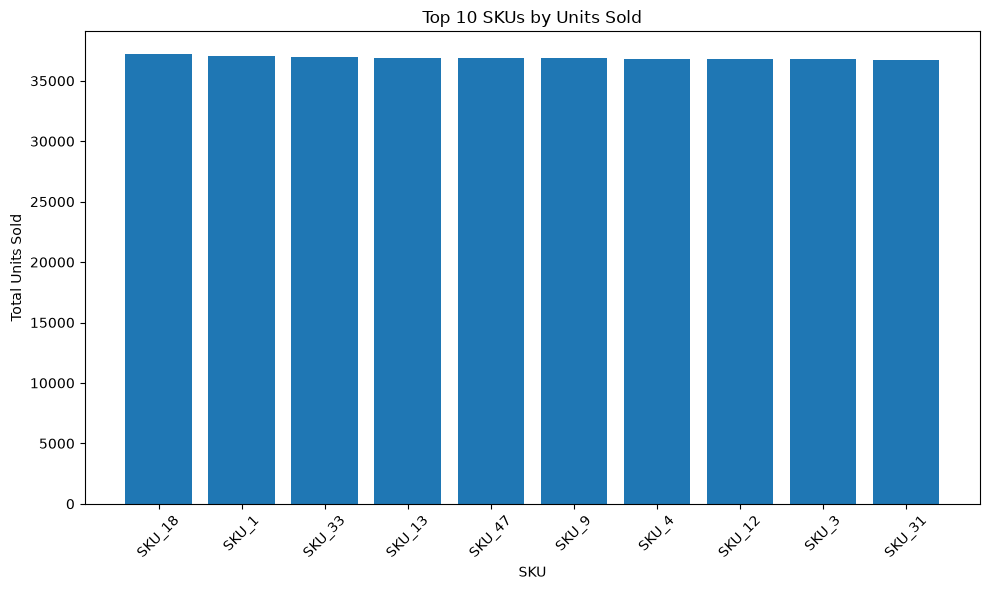

In [16]:
# Visualize Top 10 SKUs by Units Sold

top_skus = (
    sku_performance
    .sort_values("total_units_sold", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    top_skus["SKU_ID"].astype(str),
    top_skus["total_units_sold"]
)

plt.title("Top 10 SKUs by Units Sold")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 9. Supplier Performance Analysis

Supplier performance is analyzed to understand differences in delivery lead time, order quantities, and supply activity across suppliers.

The analysis aggregates supplier-level metrics to identify variations in supplier lead times and order volumes.

This can help support supplier evaluation and identify suppliers that may require closer operational monitoring.

In [17]:
# Supplier Performance Analysis

supplier_performance = (
    supply_chain
    .groupby("Supplier_ID")
    .agg(
        total_records=("SKU_ID", "count"),
        average_lead_time=("Supplier_Lead_Time_Days", "mean"),
        total_order_quantity=("Order_Quantity", "sum"),
        average_order_quantity=("Order_Quantity", "mean")
    )
    .reset_index()
)

print("Supplier Performance:")
display(
    supplier_performance
    .sort_values("total_order_quantity", ascending=False)
)

Supplier Performance:


,Supplier_ID,total_records,average_lead_time,total_order_quantity,average_order_quantity
7,SUP_7,12410,7.56,239283,19.28
8,SUP_8,10220,8.50,196023,19.18
0,SUP_1,10220,8.11,195080,19.09
1,SUP_10,9855,7.41,189525,19.23
2,SUP_2,9490,8.42,184645,19.46
4,SUP_4,9125,8.64,176568,19.35
5,SUP_5,8395,6.96,162347,19.34
3,SUP_3,8395,8.26,161721,19.26
6,SUP_6,7300,7.90,141361,19.36
9,SUP_9,5840,8.19,112062,19.19


### 9.1 Average Supplier Lead Time

The average supplier lead time is visualized across suppliers to compare delivery timelines.

A longer lead time may require additional inventory planning to maintain product availability and avoid supply disruptions.

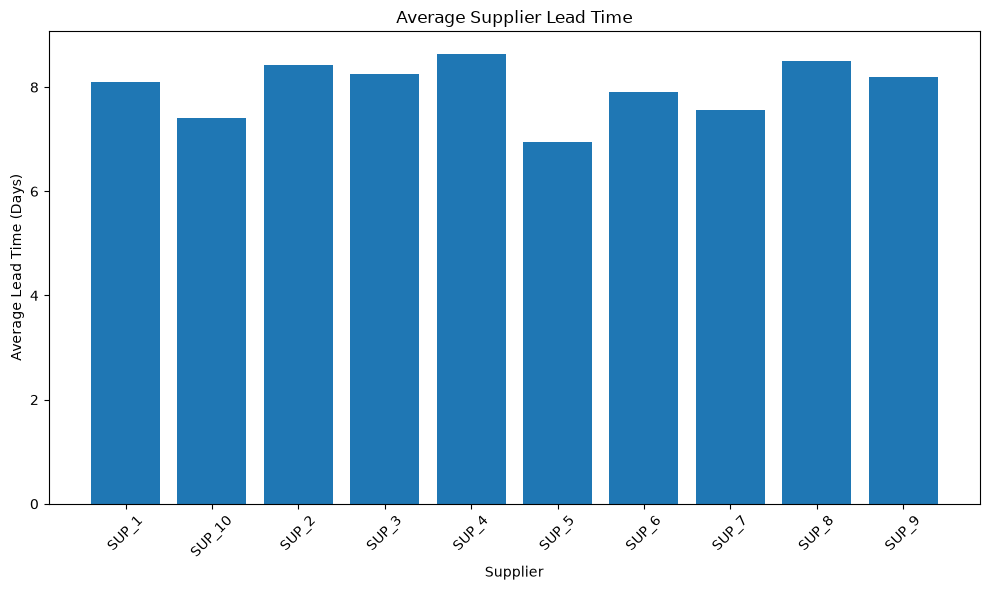

In [18]:
# Visualize Average Supplier Lead Time

plt.figure(figsize=(10, 6))

plt.bar(
    supplier_performance["Supplier_ID"].astype(str),
    supplier_performance["average_lead_time"]
)

plt.title("Average Supplier Lead Time")
plt.xlabel("Supplier")
plt.ylabel("Average Lead Time (Days)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 10. Warehouse Performance Analysis

Warehouse performance is analyzed to understand differences in sales activity, inventory levels, and order quantities across warehouses.

The analysis aggregates key operational metrics for each warehouse to identify variations in demand and inventory management.

This provides a basis for evaluating warehouse-level operational performance and resource requirements.

In [19]:
# Warehouse Performance Analysis

warehouse_performance = (
    supply_chain
    .groupby("Warehouse_ID")
    .agg(
        total_units_sold=("Units_Sold", "sum"),
        average_inventory=("Inventory_Level", "mean"),
        total_order_quantity=("Order_Quantity", "sum"),
        average_order_quantity=("Order_Quantity", "mean")
    )
    .reset_index()
)

print("Warehouse Performance:")

display(
    warehouse_performance
    .sort_values("total_units_sold", ascending=False)
)

Warehouse Performance:


,Warehouse_ID,total_units_sold,average_inventory,total_order_quantity,average_order_quantity
0,WH_1,366902,466.06,351197,19.24
2,WH_3,366110,455.56,350716,19.22
1,WH_2,366078,491.49,352574,19.32
3,WH_4,365775,477.39,351879,19.28
4,WH_5,365114,467.12,352249,19.30


### 10.1 Total Units Sold by Warehouse

The total units sold by each warehouse are visualized to compare sales activity across warehouse locations.

This visualization helps identify warehouses handling higher sales volumes and provides context for warehouse-level inventory planning.

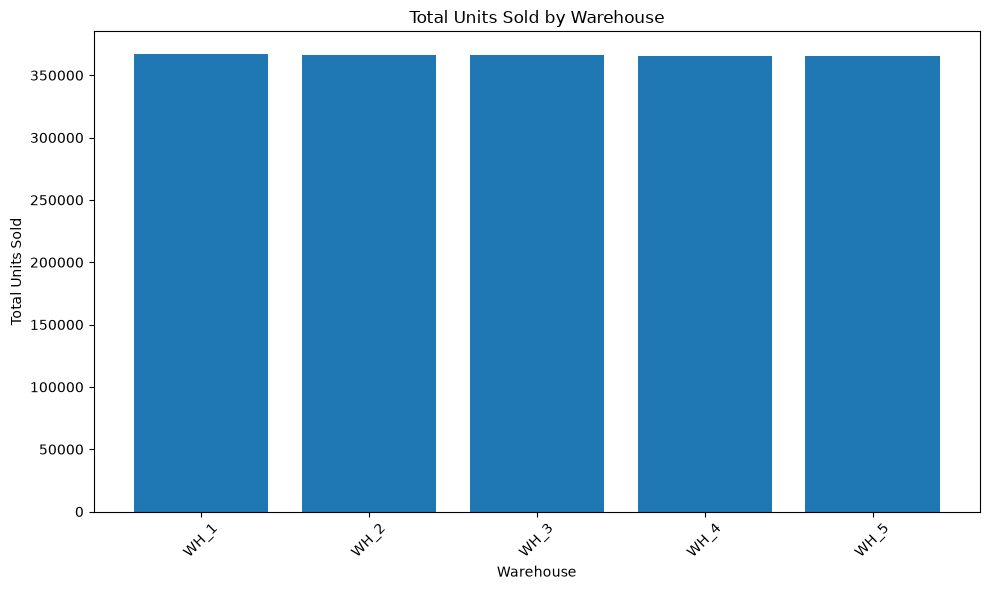

In [20]:
# Visualize Total Units Sold by Warehouse

plt.figure(figsize=(10, 6))

plt.bar(
    warehouse_performance["Warehouse_ID"].astype(str),
    warehouse_performance["total_units_sold"]
)

plt.title("Total Units Sold by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 11. Demand Forecast Analysis

Demand forecasting is analyzed by comparing actual units sold with the corresponding demand forecast.

The analysis helps evaluate how closely forecasted demand reflects actual sales activity and identifies the magnitude of forecast errors within the supply chain.

Understanding forecast accuracy can support better inventory planning, purchasing decisions, and replenishment strategies.

In [24]:
# Calculate Forecast Error

supply_chain["Forecast_Error"] = (
    supply_chain["Units_Sold"] - supply_chain["Demand_Forecast"]
)

forecast_analysis = supply_chain[
    ["Units_Sold", "Demand_Forecast", "Forecast_Error"]
].describe()

print("Demand Forecast Statistics:")

display(forecast_analysis)

Demand Forecast Statistics:


,Units_Sold,Demand_Forecast,Forecast_Error
count,"91,250.00","91,250.00","91,250.00"
mean,20.05,20.08,-0.03
std,9.07,9.50,2.99
min,0.00,0.00,-14.08
25%,13.00,12.95,-2.03
50%,20.00,19.95,-0.01
75%,27.00,26.93,1.99
max,59.00,61.42,13.00


### 11.1 Actual Demand vs Forecast

Actual units sold are compared with demand forecasts over time to evaluate how closely forecasted demand follows actual sales activity.

Visualizing both measures together makes it easier to identify periods where demand was overestimated or underestimated.

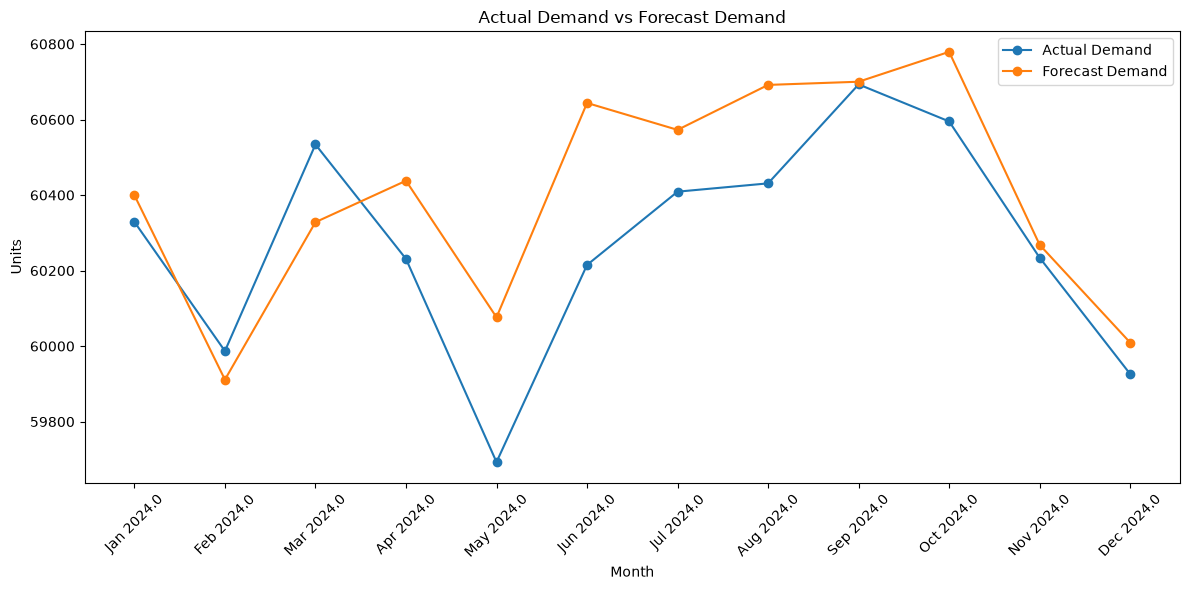

In [25]:
# Aggregate actual demand and forecast by month

monthly_forecast = (
    supply_chain
    .groupby(["Year", "Month", "Month_Name"])
    .agg(
        actual_demand=("Units_Sold", "sum"),
        forecast_demand=("Demand_Forecast", "sum")
    )
    .reset_index()
    .sort_values(["Year", "Month"])
)

# Create a readable month label

monthly_forecast["Month_Label"] = (
    monthly_forecast["Month_Name"].str[:3]
    + " "
    + monthly_forecast["Year"].astype(str)
)

# Plot actual demand vs forecast

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_forecast["Month_Label"],
    monthly_forecast["actual_demand"],
    marker="o",
    label="Actual Demand"
)

plt.plot(
    monthly_forecast["Month_Label"],
    monthly_forecast["forecast_demand"],
    marker="o",
    label="Forecast Demand"
)

plt.title("Actual Demand vs Forecast Demand")
plt.xlabel("Month")
plt.ylabel("Units")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

## 12. Forecast Error Analysis

Forecast error is analyzed to understand the difference between actual units sold and forecasted demand.

The analysis examines the distribution of forecast errors to identify whether demand was generally overestimated or underestimated.

This helps evaluate forecasting performance and provides insight into potential improvements in demand planning.

In [26]:
# Forecast Error Analysis

forecast_error_summary = (
    supply_chain["Forecast_Error"]
    .describe()
)

print("Forecast Error Statistics:")

display(forecast_error_summary)

Forecast Error Statistics:


count   91,250.00
mean        -0.03
std          2.99
min        -14.08
25%         -2.03
50%         -0.01
75%          1.99
max         13.00
Name: Forecast_Error, dtype: float64

### 12.1 Forecast Error Distribution

The distribution of forecast errors is visualized to understand the spread and frequency of forecasting deviations.

Errors close to zero indicate that forecasted demand is closer to actual demand, while larger positive or negative errors indicate greater differences between actual and forecasted demand.

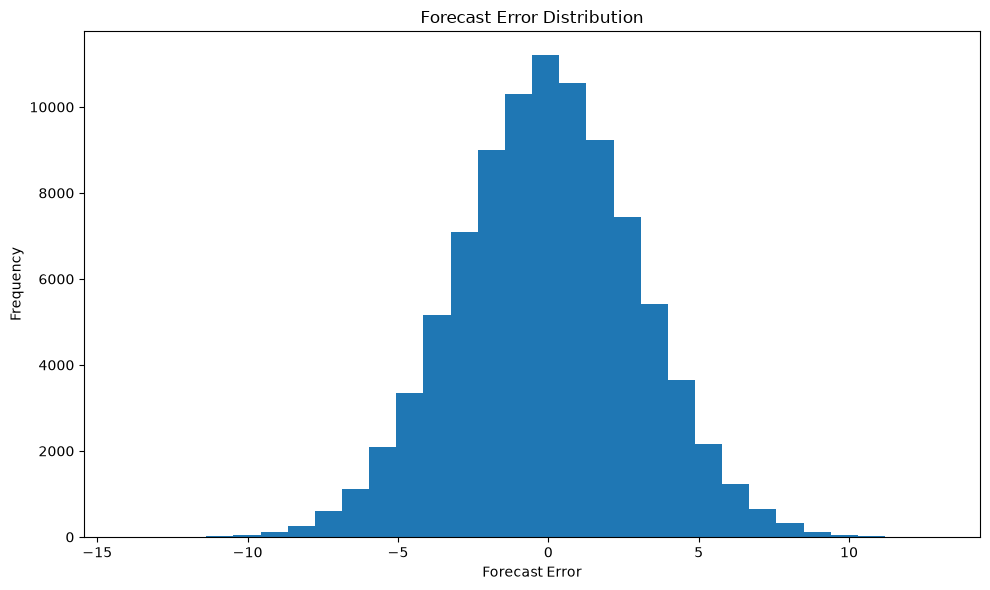

In [27]:
# Visualize Forecast Error Distribution

plt.figure(figsize=(10, 6))

plt.hist(
    supply_chain["Forecast_Error"],
    bins=30
)

plt.title("Forecast Error Distribution")
plt.xlabel("Forecast Error")
plt.ylabel("Frequency")
plt.tight_layout()

plt.show()

### 12.2 Monthly Forecast Error Trend

Monthly forecast error is analyzed to identify changes in forecasting performance over time.

Tracking the error by month helps highlight periods with relatively higher forecasting deviations and provides a clearer view of forecasting consistency throughout the year.

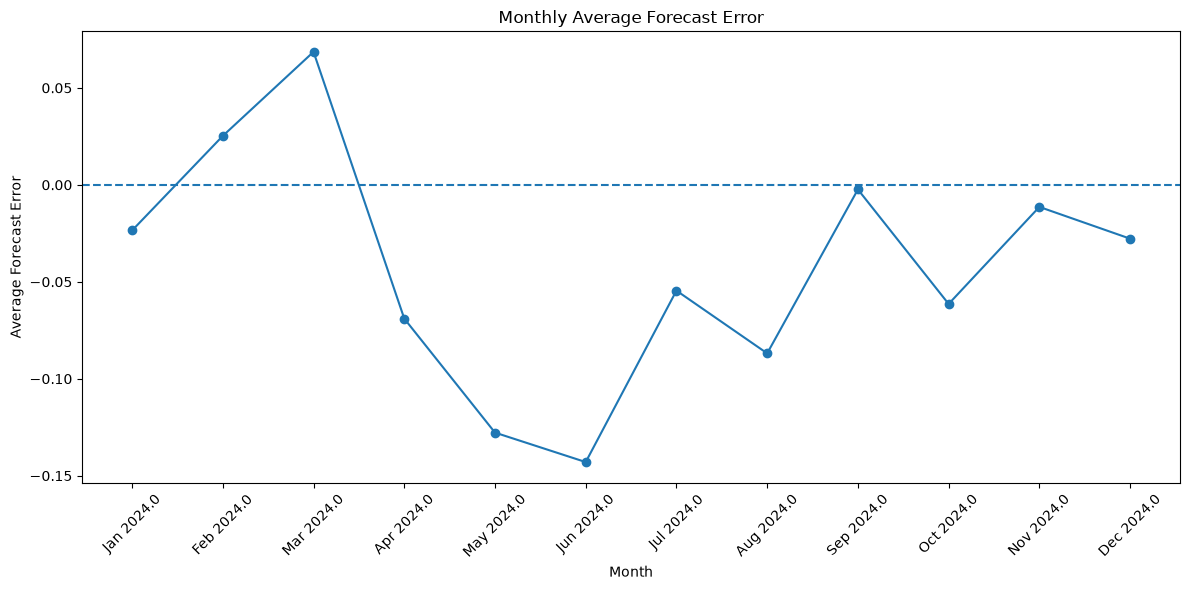

In [28]:
# Calculate monthly average forecast error

monthly_forecast_error = (
    supply_chain
    .groupby(["Year", "Month", "Month_Name"])
    .agg(
        average_forecast_error=("Forecast_Error", "mean")
    )
    .reset_index()
    .sort_values(["Year", "Month"])
)

monthly_forecast_error["Month_Label"] = (
    monthly_forecast_error["Month_Name"].str[:3]
    + " "
    + monthly_forecast_error["Year"].astype(str)
)

# Plot monthly forecast error

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_forecast_error["Month_Label"],
    monthly_forecast_error["average_forecast_error"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Monthly Average Forecast Error")
plt.xlabel("Month")
plt.ylabel("Average Forecast Error")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 13. Order Quantity & Replenishment Analysis

Order quantity is analyzed to understand replenishment patterns across the supply chain.

The analysis examines total and average order quantities to identify differences in replenishment activity and understand how inventory is being replenished across products and operational units.

This can support inventory planning and help evaluate replenishment requirements.

In [29]:
# Order Quantity Analysis

order_quantity_summary = supply_chain[
    ["Order_Quantity"]
].describe()

print("Order Quantity Statistics:")

display(order_quantity_summary)

Order Quantity Statistics:


,Order_Quantity
count,"91,250.00"
mean,19.27
std,82.34
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,499.00


### 13.1 Total Order Quantity by Warehouse

The total order quantity is visualized across warehouses to compare replenishment activity.

This helps identify warehouses receiving larger replenishment volumes and provides additional context for inventory planning and distribution decisions.

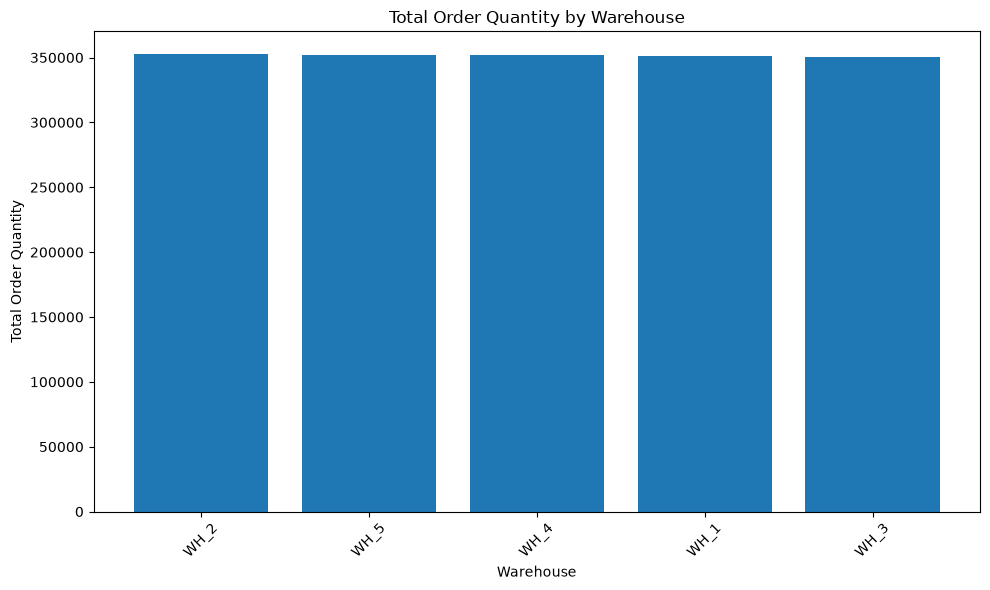

In [30]:
# Visualize Total Order Quantity by Warehouse

warehouse_orders = (
    supply_chain
    .groupby("Warehouse_ID")
    .agg(
        total_order_quantity=("Order_Quantity", "sum")
    )
    .reset_index()
    .sort_values("total_order_quantity", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    warehouse_orders["Warehouse_ID"].astype(str),
    warehouse_orders["total_order_quantity"]
)

plt.title("Total Order Quantity by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Total Order Quantity")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 14. Regional Performance Analysis

Regional performance is analyzed to understand differences in sales activity and inventory levels across geographic regions.

The analysis aggregates units sold and inventory levels by region to identify variations in demand and stock availability.

This provides a geographic perspective of supply chain performance and can support regional inventory planning.

In [31]:
# Regional Performance Analysis

regional_performance = (
    supply_chain
    .groupby("Region")
    .agg(
        total_units_sold=("Units_Sold", "sum"),
        average_inventory=("Inventory_Level", "mean"),
        total_order_quantity=("Order_Quantity", "sum")
    )
    .reset_index()
    .sort_values("total_units_sold", ascending=False)
)

print("Regional Performance:")

display(regional_performance)

Regional Performance:


,Region,total_units_sold,average_inventory,total_order_quantity
0,East,459961,473.05,455414
1,North,459849,470.79,431039
2,South,456954,472.16,442818
3,West,453215,470.09,429344


### 14.1 Total Units Sold by Region

Total units sold are visualized across regions to compare sales activity geographically.

This visualization helps identify regions with higher demand and provides a clear view of regional differences in supply chain activity.

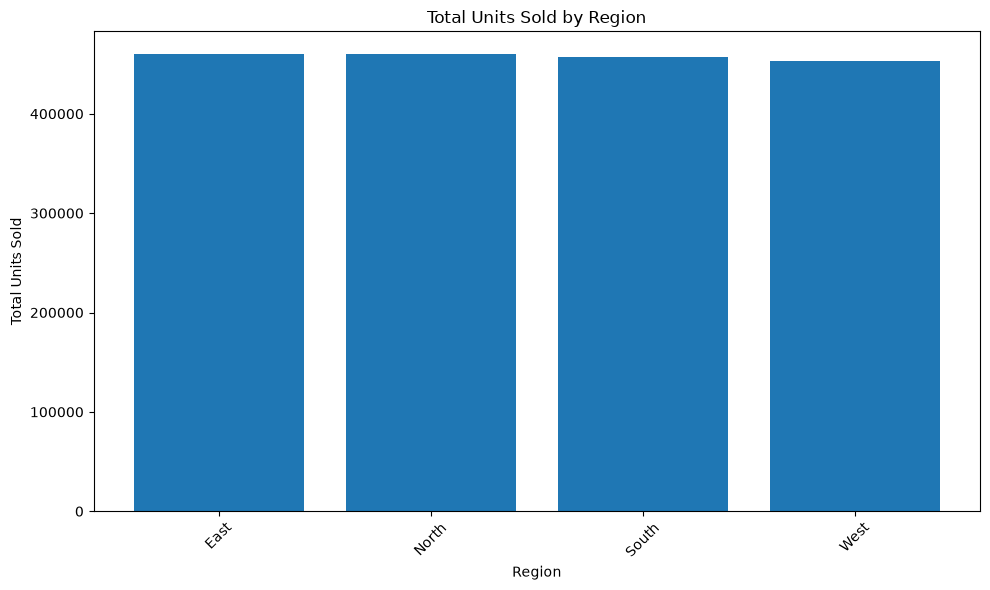

In [32]:
# Visualize Total Units Sold by Region

plt.figure(figsize=(10, 6))

plt.bar(
    regional_performance["Region"].astype(str),
    regional_performance["total_units_sold"]
)

plt.title("Total Units Sold by Region")
plt.xlabel("Region")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 15. Cost & Profitability Analysis

Cost and pricing metrics are analyzed to understand the financial characteristics of the supply chain.

The analysis compares unit cost and unit price and estimates the gross margin generated from units sold.

This provides a financial perspective on product performance and helps identify the relationship between sales volume, pricing, and profitability.

In [33]:
# Calculate product-level financial metrics

supply_chain["Revenue"] = (
    supply_chain["Units_Sold"] * supply_chain["Unit_Price"]
)

supply_chain["Cost"] = (
    supply_chain["Units_Sold"] * supply_chain["Unit_Cost"]
)

supply_chain["Gross_Profit"] = (
    supply_chain["Revenue"] - supply_chain["Cost"]
)

supply_chain["Profit_Margin"] = np.where(
    supply_chain["Revenue"] > 0,
    (supply_chain["Gross_Profit"] / supply_chain["Revenue"]) * 100,
    0
)

financial_summary = supply_chain[
    ["Revenue", "Cost", "Gross_Profit", "Profit_Margin"]
].describe()

print("Financial Performance Summary:")

display(financial_summary)

Financial Performance Summary:


,Revenue,Cost,Gross_Profit,Profit_Margin
count,"91,250.00","91,250.00","91,250.00","91,250.00"
mean,366.32,244.80,121.51,32.16
std,228.12,149.82,88.58,8.32
min,0.00,0.00,0.00,0.00
25%,194.22,131.56,56.80,25.86
50%,318.60,213.16,100.25,32.67
75%,498.87,334.85,161.73,39.71
max,"1,791.62","1,137.38",767.00,44.42


### 15.1 Gross Profit by Region

Gross profit is aggregated by region and visualized to compare the financial contribution of different geographic markets.

This provides a high-level view of where the supply chain generates greater gross profit based on units sold, selling prices, and unit costs.

In [34]:
# Calculate Gross Profit by Region

regional_profit = (
    supply_chain
    .groupby("Region")
    .agg(
        total_revenue=("Revenue", "sum"),
        total_cost=("Cost", "sum"),
        gross_profit=("Gross_Profit", "sum")
    )
    .reset_index()
    .sort_values("gross_profit", ascending=False)
)

print("Gross Profit by Region:")

display(regional_profit)

Gross Profit by Region:


,Region,total_revenue,total_cost,gross_profit
0,East,"8,398,382.40","5,608,858.39","2,789,524.01"
1,North,"8,411,171.01","5,622,773.74","2,788,397.27"
2,South,"8,320,450.82","5,558,162.63","2,762,288.19"
3,West,"8,296,332.99","5,548,341.23","2,747,991.76"


### 15.2 Gross Profit by Region

The gross profit generated by each region is visualized to provide a direct comparison of regional profitability.

This visualization highlights differences in financial contribution across regions and complements the underlying revenue and cost analysis.

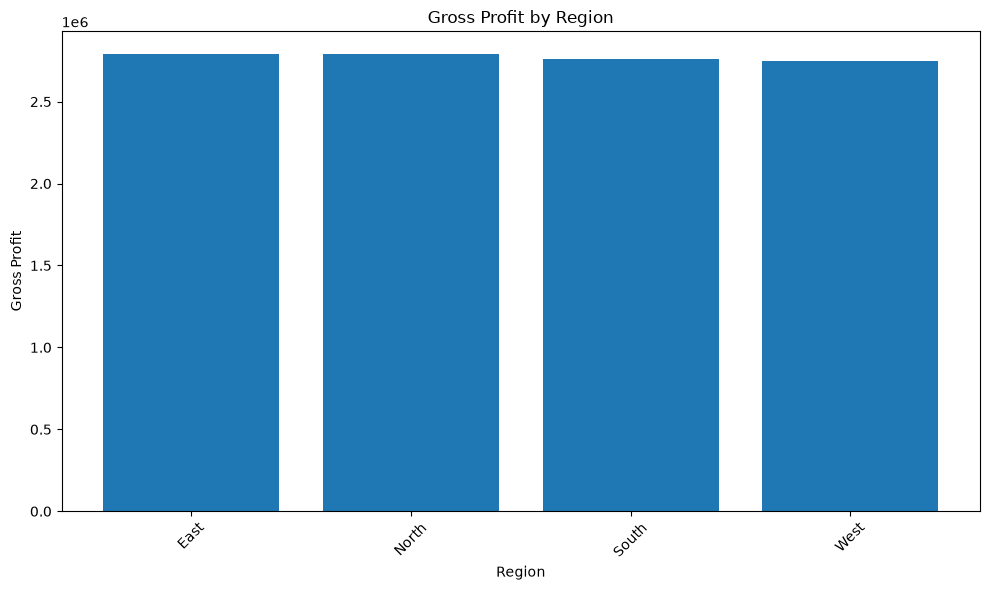

In [35]:
# Visualize Gross Profit by Region

plt.figure(figsize=(10, 6))

plt.bar(
    regional_profit["Region"].astype(str),
    regional_profit["gross_profit"]
)

plt.title("Gross Profit by Region")
plt.xlabel("Region")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 16. Monthly Supply Chain Trends

Monthly supply chain performance is analyzed to identify changes in sales, inventory, order quantities, and profitability over time.

Aggregating operational and financial metrics by month helps identify seasonal patterns, changes in demand, and variations in supply chain performance throughout the year.

In [36]:
# Monthly Supply Chain Summary

monthly_summary = (
    supply_chain
    .groupby(["Year", "Month", "Month_Name"])
    .agg(
        total_units_sold=("Units_Sold", "sum"),
        average_inventory=("Inventory_Level", "mean"),
        total_order_quantity=("Order_Quantity", "sum"),
        total_revenue=("Revenue", "sum"),
        gross_profit=("Gross_Profit", "sum")
    )
    .reset_index()
    .sort_values(["Year", "Month"])
)

monthly_summary["Month_Label"] = (
    monthly_summary["Month_Name"].str[:3]
    + " "
    + monthly_summary["Year"].astype(str)
)

print("Monthly Supply Chain Summary:")

display(monthly_summary)

Monthly Supply Chain Summary:


,Year,Month,Month_Name,total_units_sold,average_inventory,total_order_quantity,total_revenue,gross_profit,Month_Label
0,"2,024.00",1.00,January,60329,489.50,54349,"1,102,137.42","365,133.93",Jan 2024.0
1,"2,024.00",2.00,February,59987,488.40,56675,"1,096,673.34","363,716.92",Feb 2024.0
2,"2,024.00",3.00,March,60534,485.92,53098,"1,104,759.60","366,403.09",Mar 2024.0
3,"2,024.00",4.00,April,60231,482.48,49921,"1,102,769.50","365,632.00",Apr 2024.0
4,"2,024.00",5.00,May,59693,479.85,51810,"1,088,276.77","360,370.83",May 2024.0
5,"2,024.00",6.00,June,60215,476.51,50170,"1,101,821.51","366,509.43",Jun 2024.0
6,"2,024.00",7.00,July,60409,472.46,48275,"1,104,130.15","366,806.04",Jul 2024.0
7,"2,024.00",8.00,August,60431,472.20,59649,"1,104,411.25","366,024.15",Aug 2024.0
8,"2,024.00",9.00,September,60693,470.38,55231,"1,111,398.65","369,198.16",Sep 2024.0
9,"2,024.00",10.00,October,60595,471.63,64347,"1,109,860.98","368,073.98",Oct 2024.0


### 16.1 Monthly Units Sold Trend

Monthly units sold are visualized to identify changes in demand throughout the year.

The trend provides a time-based view of sales activity and can help identify periods of higher or lower demand that may require adjustments in inventory and replenishment planning.

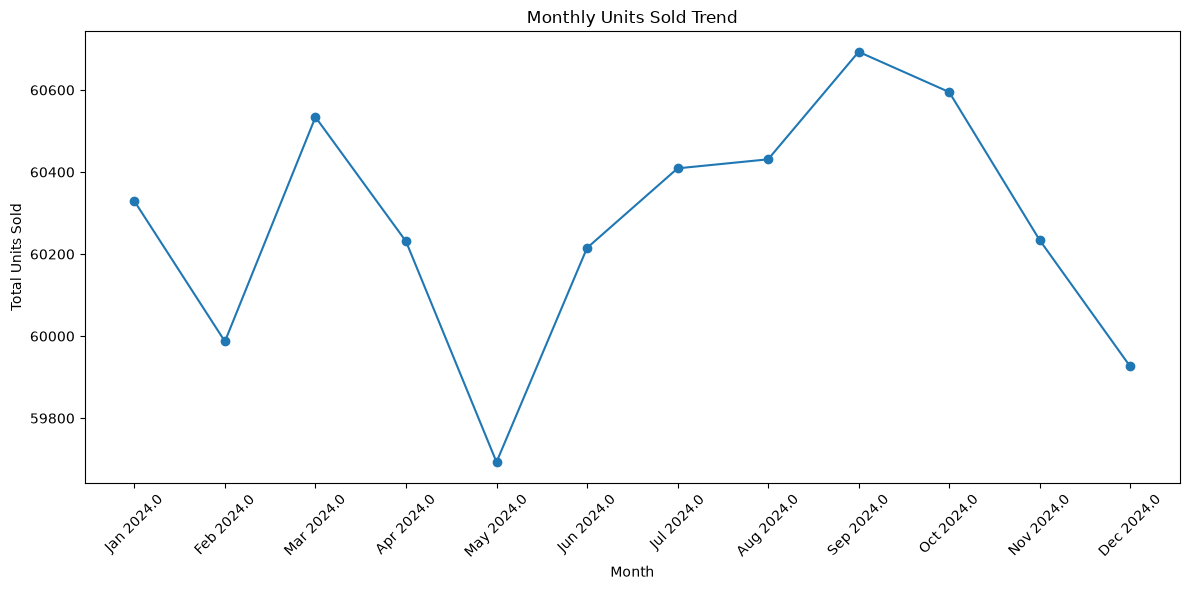

In [37]:
# Visualize Monthly Units Sold Trend

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_summary["Month_Label"],
    monthly_summary["total_units_sold"],
    marker="o"
)

plt.title("Monthly Units Sold Trend")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 16.2 Monthly Gross Profit Trend

Monthly gross profit is visualized to identify changes in profitability throughout the year.

The trend provides a time-based view of financial performance and helps highlight periods with relatively higher or lower gross profit.

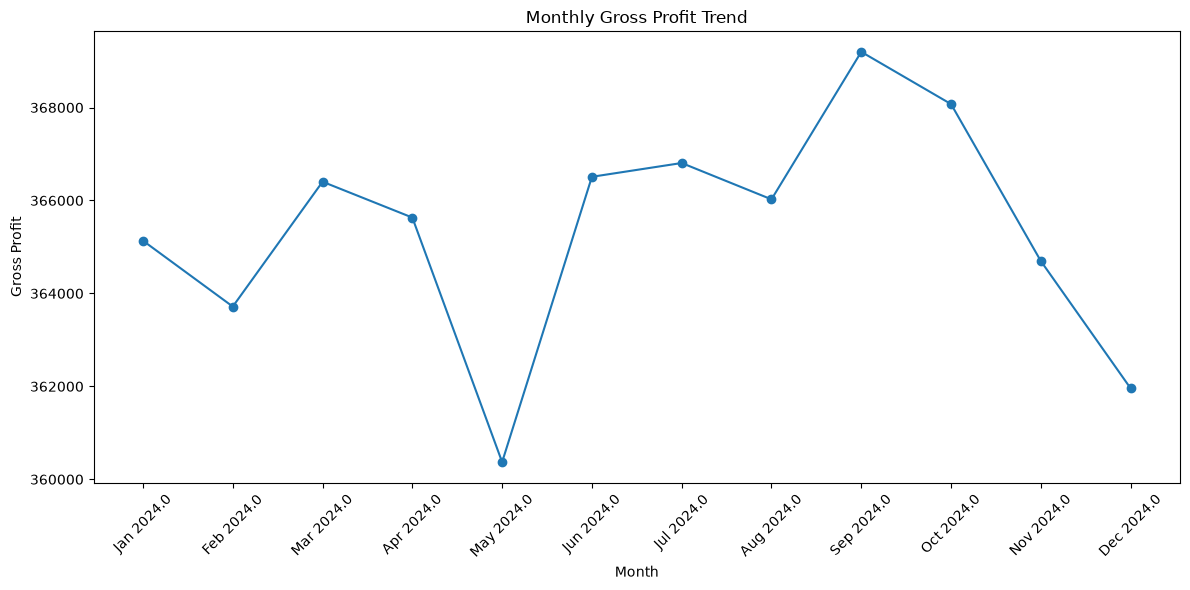

In [38]:
# Visualize Monthly Gross Profit Trend

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_summary["Month_Label"],
    monthly_summary["gross_profit"],
    marker="o"
)

plt.title("Monthly Gross Profit Trend")
plt.xlabel("Month")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 16.3 Monthly Average Inventory Trend

Monthly average inventory levels are visualized to understand how stock availability changes throughout the year.

Comparing inventory trends with sales activity can help identify periods of relatively high or low inventory and support better inventory planning.

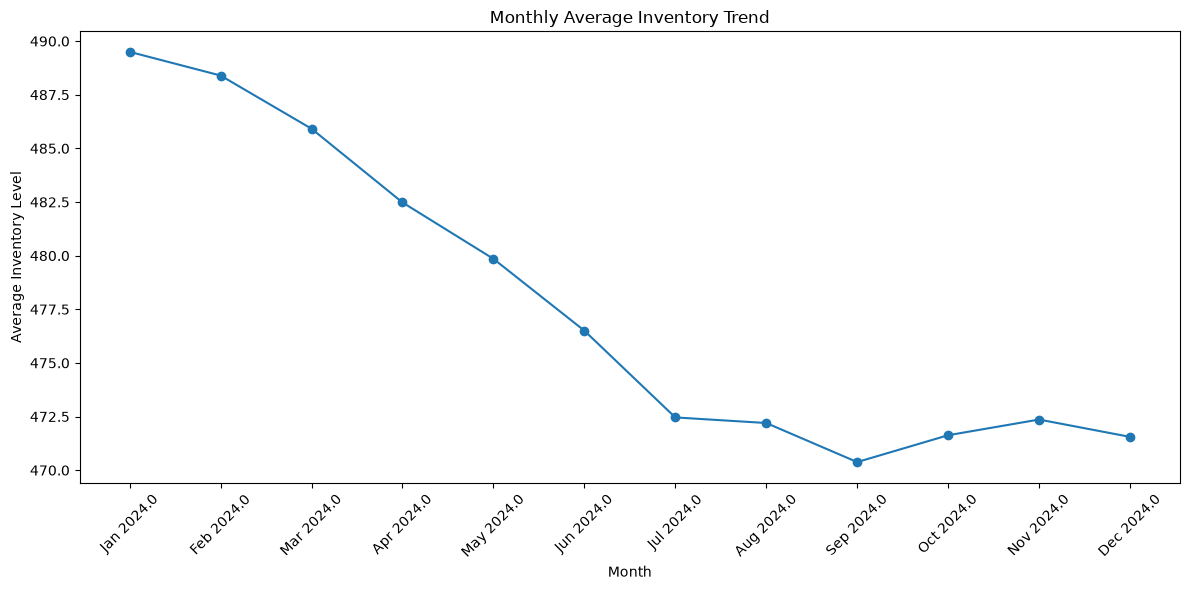

In [39]:
# Visualize Monthly Average Inventory Trend

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_summary["Month_Label"],
    monthly_summary["average_inventory"],
    marker="o"
)

plt.title("Monthly Average Inventory Trend")
plt.xlabel("Month")
plt.ylabel("Average Inventory Level")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 16.4 Monthly Order Quantity Trend

Monthly order quantities are visualized to understand changes in replenishment activity throughout the year.

Comparing order quantities over time can help identify periods of increased replenishment requirements and provide additional context for inventory planning.

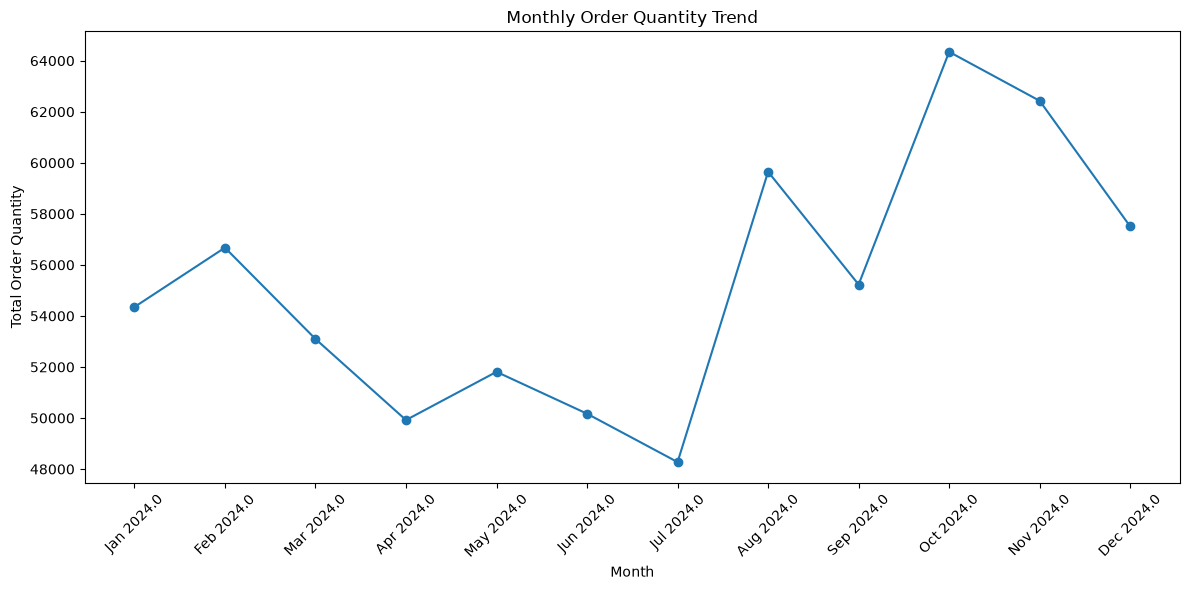

In [40]:
# Visualize Monthly Order Quantity Trend

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_summary["Month_Label"],
    monthly_summary["total_order_quantity"],
    marker="o"
)

plt.title("Monthly Order Quantity Trend")
plt.xlabel("Month")
plt.ylabel("Total Order Quantity")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 17. Overall Supply Chain KPI Summary

A consolidated KPI summary is created to provide a high-level overview of supply chain performance.

The summary combines key sales, inventory, supplier, order, financial, and forecasting metrics calculated throughout the analysis.

These KPIs provide a concise view of overall operational performance and can also serve as the foundation for the final Power BI dashboard.

In [41]:
# Overall Supply Chain KPI Summary

kpi_summary = {
    "Total Records": len(supply_chain),
    "Total Units Sold": supply_chain["Units_Sold"].sum(),
    "Average Inventory Level": supply_chain["Inventory_Level"].mean(),
    "Average Supplier Lead Time (Days)": supply_chain["Supplier_Lead_Time_Days"].mean(),
    "Total Order Quantity": supply_chain["Order_Quantity"].sum(),
    "Total Revenue": supply_chain["Revenue"].sum(),
    "Total Gross Profit": supply_chain["Gross_Profit"].sum(),
    "Average Profit Margin (%)": supply_chain["Profit_Margin"].mean(),
    "Average Forecast Error": supply_chain["Forecast_Error"].mean()
}

kpi_summary_df = pd.DataFrame(
    kpi_summary.items(),
    columns=["KPI", "Value"]
)

display(kpi_summary_df)

,KPI,Value
0,Total Records,"91,250.00"
1,Total Units Sold,"1,829,979.00"
2,Average Inventory Level,471.52
3,Average Supplier Lead Time (Days),7.98
4,Total Order Quantity,"1,758,615.00"
5,Total Revenue,"33,426,337.22"
6,Total Gross Profit,"11,088,201.23"
7,Average Profit Margin (%),32.16
8,Average Forecast Error,-0.03


## 18. Key Findings & Conclusion

The analysis provides an overall view of supply chain performance across sales, inventory, suppliers, warehouses, forecasting, replenishment, and financial performance.

### Key Areas Identified

- **Sales & Demand:** Monthly and SKU-level analysis highlights differences in demand across products and periods.
- **Inventory:** Inventory levels and inventory turnover provide insight into stock utilization and inventory efficiency.
- **Suppliers:** Supplier lead-time analysis highlights differences in delivery timelines across suppliers.
- **Warehouses:** Warehouse-level analysis identifies differences in sales and replenishment activity.
- **Forecasting:** Actual demand and forecast demand were compared to evaluate forecasting deviations.
- **Replenishment:** Order quantity analysis provides insight into inventory replenishment patterns.
- **Regional Performance:** Regional analysis highlights differences in sales and profitability across geographic areas.
- **Financial Performance:** Revenue, cost, gross profit, and profit margin were calculated to evaluate the financial contribution of supply chain activity.

### Conclusion

The Python analysis establishes a foundation for deeper supply chain analysis by combining operational, forecasting, inventory, and financial metrics.

The next stage of the project will reproduce and extend these business analyses using **SQL Server**, followed by the development of an interactive **Power BI dashboard**.